Notebook para fazer visualizações e comparações entre distribuições CPRI e Poisson.

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, errno
import sys
from math import sqrt

#Settings
PRED_ALG = 'mlp'
BASE_DIR = 'test_poissonPG_IPACT_pred_{}'.format(PRED_ALG)
NUMBER_OF_OLTs = 1
NUMBER_OF_ONUs = 20
DISTANCE = 20 #Distance in kilometers
TRAFFIC = "poisson"
DBA_ALG = "ipact_pred"


IPACT_Pred_grant_medio = {}
ipact_basic_grant_medio = {}
IPACT_Pred_std = {}
ipact_basic_std = {}
IPACT_Pred_grant_percent_mean = {}
IPACT_Pred_grant_percent_std = {}
#load % values which represents each exponent
#loads = [25,31,37,43,50,56,62,68,75,81,87,93]
loads = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]
#pkt arrival distribution exponents
#exponents = [1160, 1450, 1740, 2030, 2320, 2610, 2900, 3190, 3480, 3770, 4060, 4350]
exponents = [0.01, 0.05, 0.1, 0.20, 0.30, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
# To do a complete test: uncomment the line below
#seeds = [20,30,40,50,60,70,80,90,100,110] #random seeds
# To do a FAST test: uncomment the line below
seeds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
#parameters = [{'w':12, 'p':1}]
parameters = [{'w':25, 'p':1}]
#parameters = [{'w':30, 'p':2}, {'w':20, 'p':2}, {'w':25, 'p':2}, {'w':15, 'p':2}]
#PKT_SIZES = ['1536000']
#PKT_SIZES = ['768000']
PKT_SIZES = ['768000', '1536000', '3072000', '3840000']

for size in PKT_SIZES:
    IPACT_Pred_grant_medio[size] = {}
    ipact_basic_grant_medio[size] = {}
    IPACT_Pred_std[size] = {}
    ipact_basic_std[size] = {}
    IPACT_Pred_grant_percent_mean[size] = {}
    IPACT_Pred_grant_percent_std[size] = {}

In [122]:
def calculateT_student(vetor_medias, f_degrees):
    table_const = 2.262
    media_final = np.mean(vetor_medias)
    std_final = np.std(vetor_medias)
    interval_amp = table_const*std_final/(sqrt(f_degrees))
    
    structured_resp = {'t-test amp': interval_amp, 't-test interval': [media_final-interval_amp, media_final+interval_amp]}

    return structured_resp

Leitura dos dados gerados em tráfego Poisson e criação de dataframe (Alterado para lidar com múltiplas seeds e combinações de 'w' e 'p').

In [123]:
for params in parameters:
    for exp in exponents:
        for payload_size in PKT_SIZES:
            ipact_mean = []
            ipact_grant_percentages = []
            for seed in seeds:
                df_tmp = pd.read_csv("{}/{}km/{}/csv/grant_usage/{}-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-w{}-p{}-s{}-grant_usage.csv".format(BASE_DIR, DISTANCE, payload_size, DBA_ALG, DISTANCE,
                                                                                                    NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                    TRAFFIC, exp, payload_size, params['w'], params['p'], seed))
                ipact_mean.append(df_tmp['data sent'].mean())
                n_pred_grants = df_tmp[df_tmp['predicted'] == True].shape[0]
                
                n_grants = df_tmp.shape[0]
                percentage = n_pred_grants/n_grants
                ipact_grant_percentages.append(percentage*100)
            
            media = np.mean(ipact_mean)
            #std = np.mean(std_pkt_loss)
            t_test_results = calculateT_student(ipact_mean, 10)
            std = t_test_results['t-test amp']
            IPACT_Pred_grant_medio[payload_size][exp] = media
            IPACT_Pred_std[payload_size][exp] = std

            percentage_media = np.mean(ipact_grant_percentages)
            #percentage_std = np.std(ipact_grant_percentages)
            #std = np.mean(std_pkt_loss)
            t_test_results = calculateT_student(percentage_media, 10)
            percentage_std = t_test_results['t-test amp']
            IPACT_Pred_grant_percent_mean[payload_size][exp] = percentage_media
            IPACT_Pred_grant_percent_std[payload_size][exp] = percentage_std

ipact_df_pr_medias = pd.DataFrame(IPACT_Pred_grant_medio)
ipact_df_pr_stds = pd.DataFrame(IPACT_Pred_std)
ipact_df_percentages_media = pd.DataFrame(IPACT_Pred_grant_percent_mean)
ipact_df_percentages_std = pd.DataFrame(IPACT_Pred_grant_percent_std)

In [124]:
ipact_df_pr_medias

,768000,1536000,3072000,3840000
0.01,306108.896797,613500.000000,1.228937e+06,1.536000e+06
0.05,323423.211135,646160.001085,1.298917e+06,1.614291e+06
0.10,333429.192267,665063.421067,1.326887e+06,1.663065e+06
0.20,340621.630520,681669.822904,1.410235e+06,1.829093e+06
0.30,346486.055872,700025.603304,1.548662e+06,2.003820e+06
0.40,349928.687141,732236.531346,1.636755e+06,2.081982e+06
0.50,355452.029619,766136.803876,1.683385e+06,2.139783e+06
0.60,363412.103029,793197.006035,1.716830e+06,2.168945e+06
0.70,372729.727301,813227.115880,1.741393e+06,2.202222e+06
0.80,379880.962001,828149.152215,1.764954e+06,2.222715e+06


Ipact básico

In [125]:
for exp in exponents:
    for payload_size in PKT_SIZES:
        ipact_mean = []
        ipact_std = []
        for seed in seeds:
            df_tmp = pd.read_csv("test_poissonPG_IPACT/{}km/{}/csv/grant_usage/ipact-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-s{}-grant_usage.csv".format(DISTANCE, payload_size, DISTANCE,
                                                                                                                          NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                                          TRAFFIC, exp, payload_size, seed))
            ipact_mean.append(df_tmp['data sent'].mean())

        media = np.mean(ipact_mean)
        #std = np.mean(std_pkt_loss)
        t_test_results = calculateT_student(ipact_mean, 10)
        std = t_test_results['t-test amp']
        ipact_basic_grant_medio[payload_size][exp] = media
        ipact_basic_std[payload_size][exp] = std
ipact_b_df_medias = pd.DataFrame(ipact_basic_grant_medio)
ipact_b_df_stds = pd.DataFrame(ipact_basic_std)

In [126]:
ipact_b_df_medias

,768000,1536000,3072000,3840000
0.01,306108.896797,613500.000000,1.228937e+06,1.536000e+06
0.05,306170.615306,613681.321283,1.229446e+06,1.537537e+06
0.10,306391.050852,614316.012311,1.231282e+06,1.540762e+06
0.20,306917.307666,616138.584075,1.311861e+06,1.708414e+06
0.30,307548.383856,632572.422816,1.416406e+06,1.810741e+06
0.40,309780.043986,678758.965187,1.464078e+06,1.861443e+06
0.50,320969.654527,704036.977903,1.494407e+06,1.896653e+06
0.60,335877.583818,720412.469313,1.516801e+06,1.927102e+06
0.70,345258.403386,731769.992975,1.539820e+06,1.954837e+06
0.80,352329.939497,741254.251869,1.555014e+06,1.980652e+06


Abertura de figura e edição de título.

<Figure size 640x480 with 0 Axes>

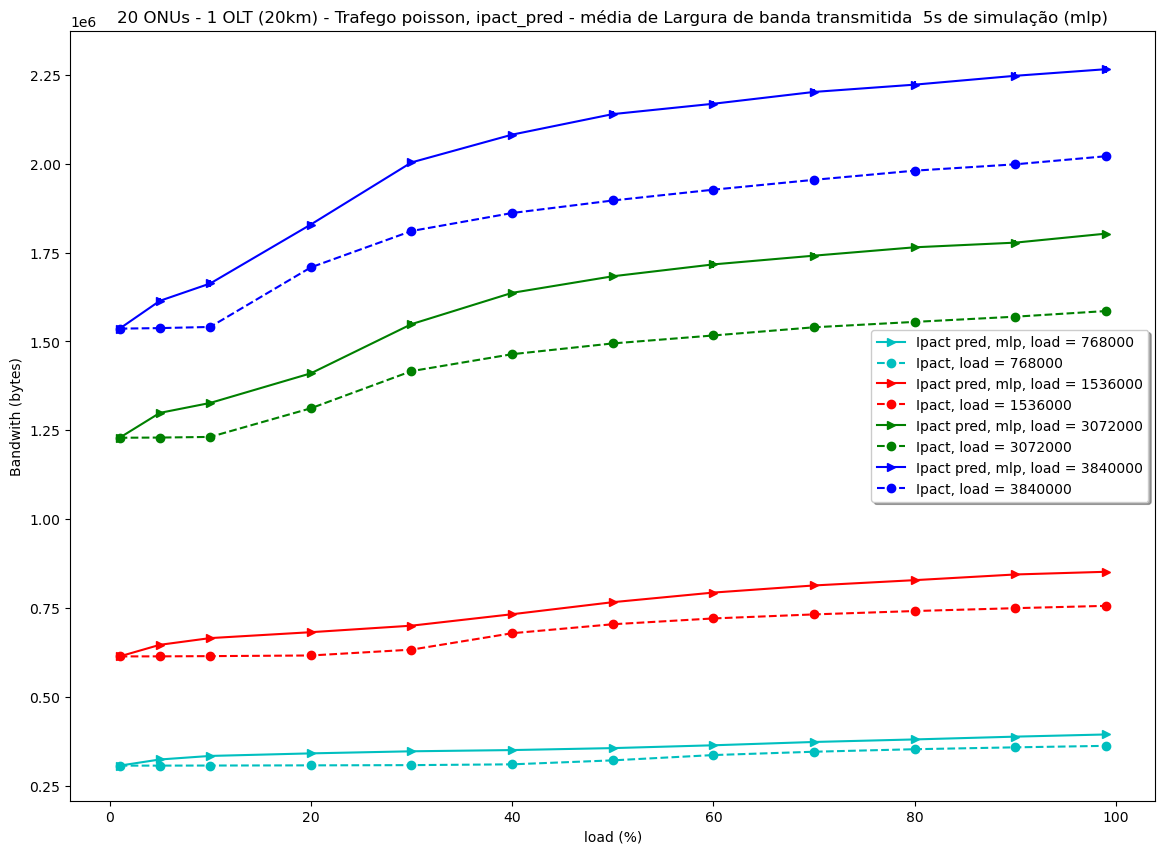

In [127]:
plt.clf()
plt.figure(figsize=(14, 10))
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - média de Largura de banda transmitida  5s de simulação ({})".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG, PRED_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("Bandwith (bytes)")
plt.yscale('linear')
cmap = plt.get_cmap('gnuplot')
colors = ['c', 'r', 'g', 'b']
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")

i=0
for payload_size in PKT_SIZES:
    aux_df = pd.DataFrame(ipact_df_pr_medias[payload_size])
    aux_label = "Ipact pred, {}, load = {}".format(PRED_ALG, payload_size)
    media_delay = np.array(aux_df.iloc[:,0])
    aux_df = pd.DataFrame(ipact_df_pr_stds[payload_size])
    std_delay = np.array(aux_df.iloc[:,0])
    #print(std_delay)
    
    plt.plot(loads, media_delay, '->', color=colors[i], label=aux_label)
    plt.errorbar(loads, media_delay, std_delay, color=colors[i], linestyle='None')
    
    aux_df_b_ipact = pd.DataFrame(ipact_b_df_medias[payload_size])
    aux_label = "Ipact, load = {}".format(payload_size)
    media_delay = np.array(aux_df_b_ipact.iloc[:,0])
    plt.plot(loads, media_delay, '--o', color=colors[i], label=aux_label)
    i += 1
      
plt.legend(loc='best', shadow=True)
plt.savefig(title)
plt.show()


<Figure size 640x480 with 0 Axes>

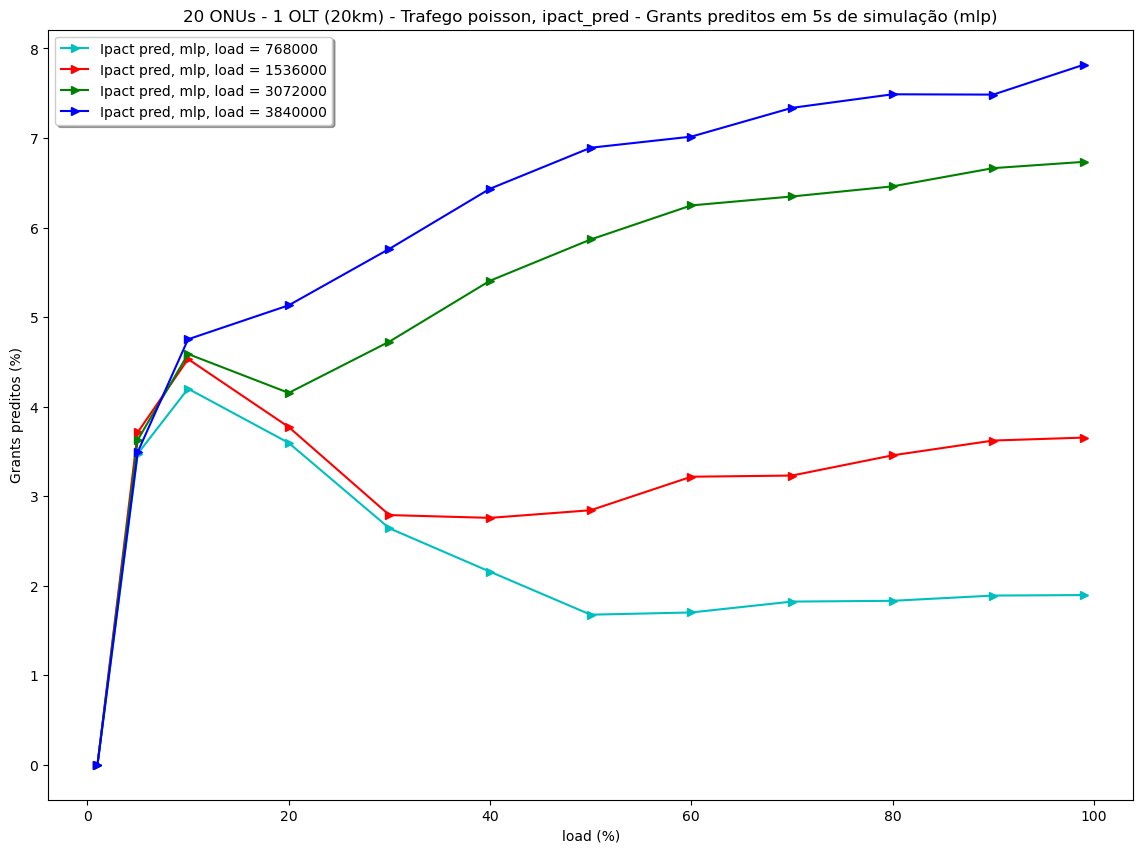

In [128]:
plt.clf()
plt.figure(figsize=(14, 10))
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - Grants preditos em 5s de simulação ({})".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG, PRED_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("Grants preditos (%)")
plt.yscale('linear')
cmap = plt.get_cmap('gnuplot')
colors = ['c', 'r', 'g', 'b']
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")

i=0
for payload_size in PKT_SIZES:
    aux_df = pd.DataFrame(ipact_df_percentages_media[payload_size])
    aux_label = "Ipact pred, {}, load = {}".format(PRED_ALG, payload_size)
    media_delay = np.array(aux_df.iloc[:,0])
    aux_df = pd.DataFrame(ipact_df_percentages_std[payload_size])
    std_delay = np.array(aux_df.iloc[:,0])
    #print(std_delay)
    
    plt.plot(loads, media_delay, '->', color=colors[i], label=aux_label)
    plt.errorbar(loads, media_delay, std_delay, color=colors[i], linestyle='None')
    
    i += 1
      
plt.legend(loc='best', shadow=True)
plt.savefig(title)
plt.show()
